In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
df = pd.read_csv('housing.csv')

# 2. Handling Missing Values
# In this dataset, 'total_bedrooms' usually has missing values.
imputer = SimpleImputer(strategy="median")
df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])

# 3. Categorical Encoding (Ocean Proximity)
# Using One-Hot Encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("Data cleaning and encoding complete.")
print(df.info())

Data cleaning and encoding complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  bool   
 10  ocean_proximity_ISLAND      20640 non-null  bool   
 11  ocean_proximity_NEAR BAY    20640 non-null  bool   
 12  ocean_proximity_NEAR OCEAN  20640 non-null  bool   

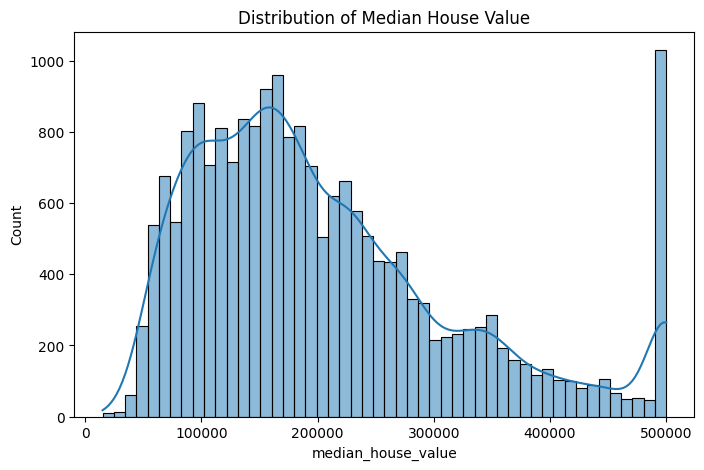

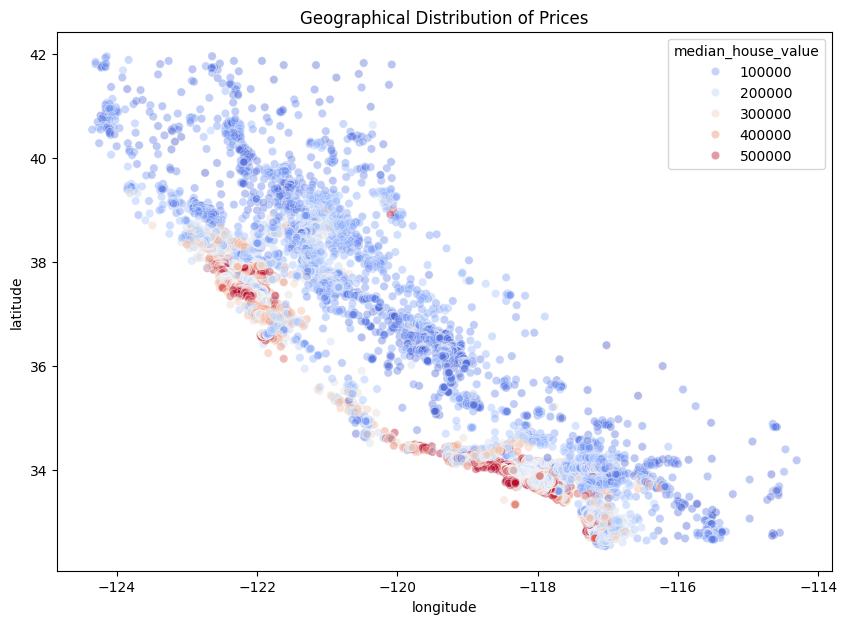

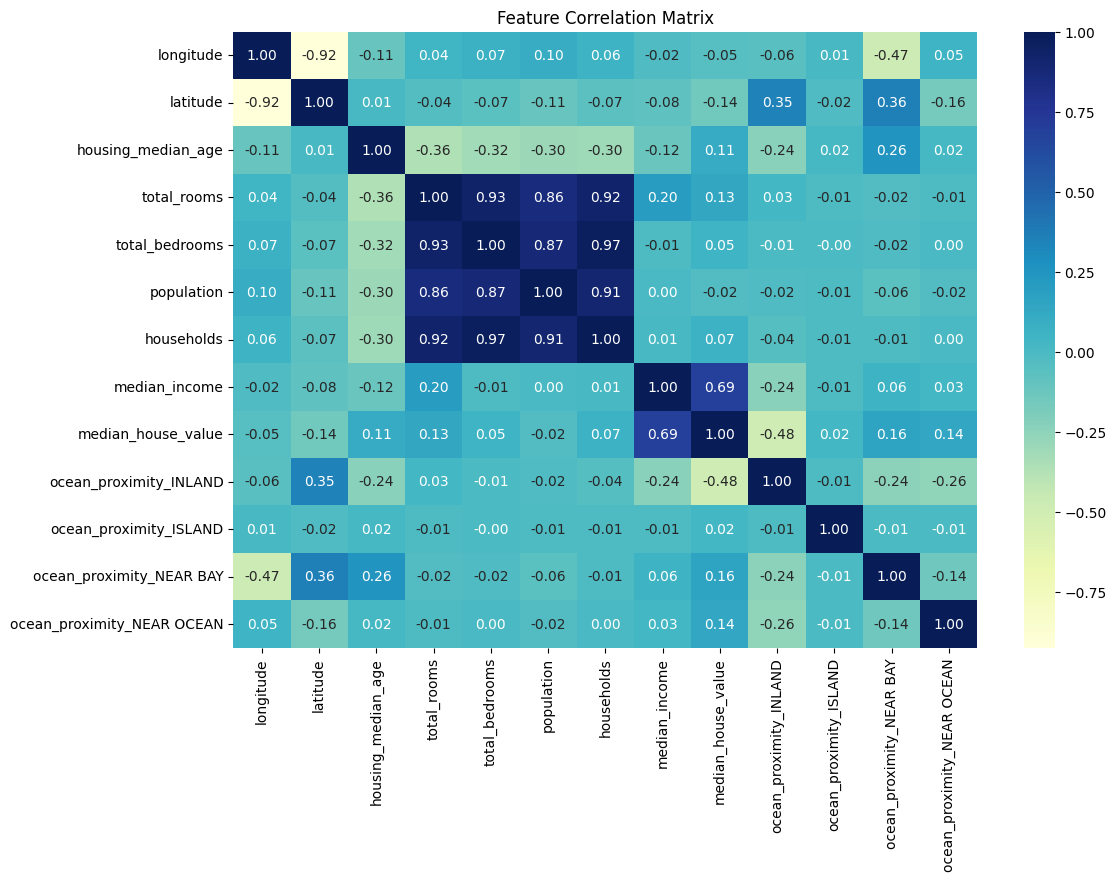

In [2]:
# 1. Histogram of Median House Value
plt.figure(figsize=(8, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.show()

# 2. Scatter Plot: Latitude vs Longitude (colored by price)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='median_house_value', palette='coolwarm', alpha=0.4)
plt.title('Geographical Distribution of Prices')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [3]:
# 1. Creating New Features (as suggested in typical housing tasks)
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# 2. Split Data
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# 4. Predictions and Evaluation
y_pred = lin_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

Root Mean Squared Error (RMSE): $72,668.54
R-squared Score: 0.5970
